## Hector Pena
## DSC 630

### Project Milestone 1

### I am a cast member at the Disneyland Resort in Anaheim, California. In this project I will sign light onto the injures over a 20 year period at theme parks across the United States and compare the different type of injuries that are reported and categorize them based on specific parameters. I want to answer the question of is there a trend of when specific injuries happen. Is there a specific time of year that has more injuries. I want to create a model to try and predict age groups that will be porne the most to injury.

### Below  is the dataset cleaning and extraction for the first set of data being the CSV file found on Kaggle, this dataset was sourced from a legit website that provides different type of datasets to use in the education sector as-well-as in the private sector. At a first glance at my dataset there are a lot of unnecesarry information that needs to be removed and a lot of information that is inputed.

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df=pd.read_csv('../dsc630/datasets/themepark_incident_data.csv')
df.head()

,Company,Incident_date,Ride_name_dirty,Ride_name,Theme_Park,age_gender,description
0,Disney World,06/09/2022,Alien Swirling Saucers,Alien Swirling Saucers,Hollywood Studios,59 yof,guest with pre-existing condition sustained in...
1,Disney World,10/05/2014,Astro Orbiter,Astro Orbiter,Magic Kingdom,68 yom,"guest fell exiting vehicle, developed blood c..."
2,Disney World,12/03/2009,Astro Orbitor,Astro Orbiter,Magic Kingdom,40 yof,fractured left ankle exiting ride
3,Disney World,08/07/2022,Avatar Flight of Passage,Avatar Flight of Passage,Animal Kingdom,83 yom,guest with pre-existing condition was briefly ...
4,Disney World,4/19/22,Avatar Flight of Passage,Avatar Flight of Passage,Animal Kingdom,42 yof,guest with pre-existing condition had motion s...


In [12]:
df['Company'] = df['Company'].map(lambda x: x.replace(':', ''))

In [13]:
### Step 1 of data transformation
# Convert incident date from object to datetime using mixed format
df['Incident_date'] = pd.to_datetime(df['Incident_date'],format='mixed')

In [14]:
df['day_of_month'] = df['Incident_date'].dt.day
df['month_of_incident'] = df['Incident_date'].dt.month
df['year_of_incident'] = df['Incident_date'].dt.year

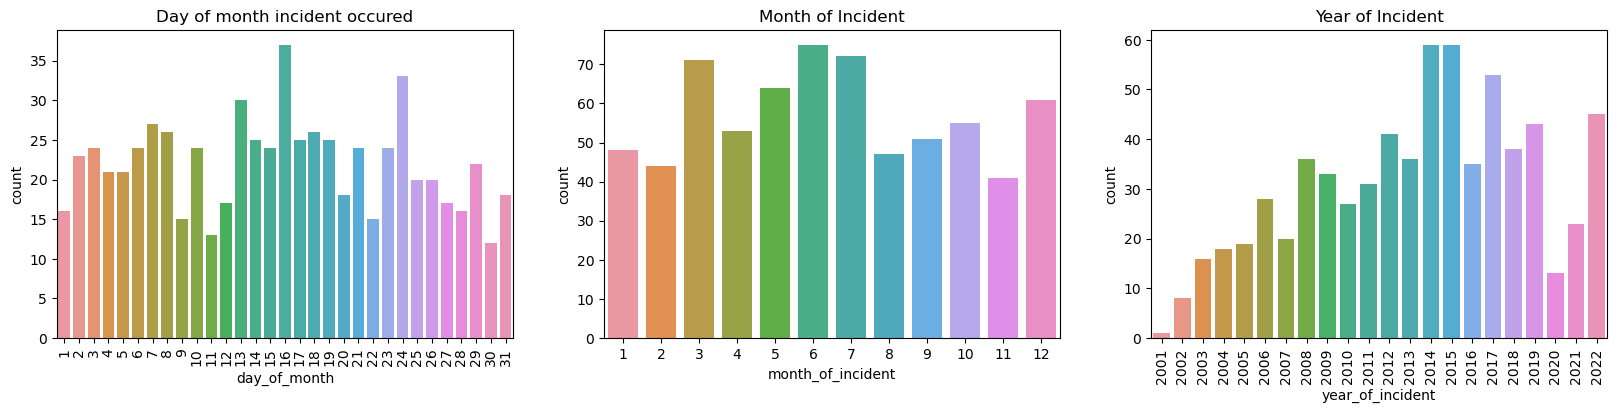

In [15]:
### print bar graphs that show incidents clustered in days of month, month, and years to see if there are any trends
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,4), sharey=False)

c1 = sns.countplot(x=df['day_of_month'], ax=axes[0])
sns.countplot(x=df['month_of_incident'], ax=axes[1])
c2 = sns.countplot(x=df['year_of_incident'], ax=axes[2])

axes[0].set_title('Day of month incident occured')
axes[1].set_title('Month of Incident')
axes[2].set_title('Year of Incident')

c1.set_xticklabels(c1.get_xticklabels(), rotation=90)
c2.set_xticklabels(c2.get_xticklabels(), rotation=90)
None

### Above we can see a graphical distribution of the injuries broken down; daily, monthly, and yearly. We cannot assume any type of correlation as the data shows a random distribution with having multiple peaks of injuries throughout the years, months, and days of reported injuries.

In [16]:
# remove any leading/trailing white space from the age_gender column
df['age_gender'] = df['age_gender'].str.strip()
# Take the last character of the string and use this as gender
df['gender'] = df['age_gender'].str[-1:]
# With the assumption all our guests are under 100  years old to be visiting theme parks I am taking
# the first 2 characters of the age_gender column and use this to populate the age column
df['age'] = df['age_gender'].str[:2]
# remove any white space for guests that are less than 10 years old and store this as an integer.
df['age'] = df['age'].str.strip().astype(int)
# With age and gender extracted we can now remove the age_gender column from our original dataframe.
df.drop(columns=['age_gender'], inplace=True)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


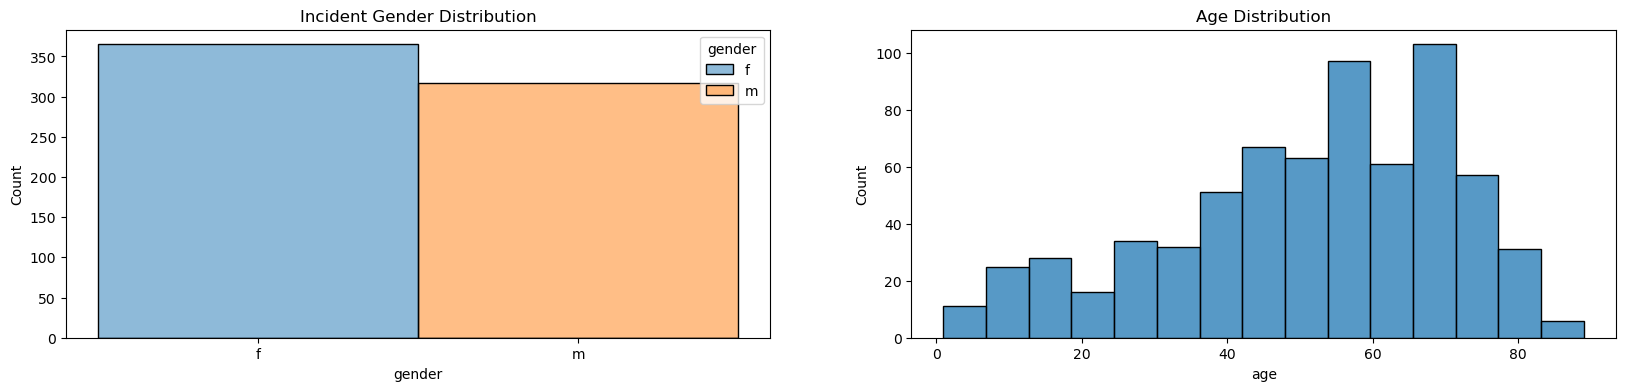

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,4), sharey=False)

sns.histplot(x=df['gender'], hue=df['gender'], ax=axes[0])
sns.histplot(x=df['age'], ax=axes[1])

axes[0].set_title('Incident Gender Distribution')
axes[1].set_title('Age Distribution')
None

### Above we can graphically see the gender and age distribution for the injuries, we can see that women are more prone to getting injured, and the ages who show the most injuries are that of 40 and above.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='age_category', ylabel='count'>

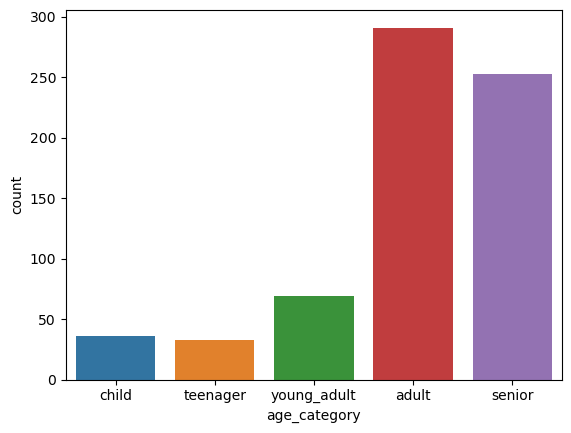

In [18]:
# Child = 0-12
# Teenager = 13-19
# Young Adult = 20-34
# Adult = 35-59
# Senior = 60+

df['age_category'] = pd.cut(df['age'], bins=[0, 12, 20, 35, 60, 90], 
                            labels=['child', 'teenager', 'young_adult', 'adult', 'senior'])
sns.countplot(x=df['age_category'])

### Above is a graphical representation of the different age groups in relation to how many injuries each has, we can see that the adults and seniors take the win as both of these age groups jave over 250 reported injuries each.

In [19]:
def ride_category(ride_name):
    thrill_ride = ['Harry Potter and the Forbidden Journey', 'Mission: Space', 'Test Track', 'Back to the Future',
                   'Dinosaur', "Dr Doom's Fearfall", 'Men In Black', "Soarin' Around the World", 'Star Tours: The Adventure Continues',
                   'The Twilight Zone Tower of Terror', "Avatar Flight of Passage", "Disaster", "Fast & Furious - Supercharged",
                   "Halloween Horror Nights", "Harry Potter and the Escape from Gringotts", "Millennium Falcon: Smugglers Run",
                   "Star Wars: Rise of the Resistance", "Storm Force Acceleration", "The Amazing Adventures of Spiderman", 
                   "The Simpsons Ride", "Transformers: The Ride 3D"]
    family_ride = ['Carousel of Progress', 'Dumbo', 'Great Movie Ride', 'Haunted Mansion', 'Kilimanjaro Safaris Expedition',
                   'The Liberty Belle', 'Mad Tea Party', "Peter Pan's Flight", 'Pirates of the Caribbean', 
                   'Spaceship Earth', "Ellen's Energy Adventure", "Alien Swirling Saucers", "Astro Orbiter", "Chair Lift", 
                   "Buzz Lightyears Space Ranger Spin", "Camp Jurassic", "Caro-Seuss-el", "Despicable Me Minion Mayhem",
                   "The Cat In The Hat", "E.T Adventure", "Fievel's Playground", "Flight of the Hippogriff", "Frozen Ever After",
                   "Gran Fiesta Tour Attraction", "Honey I Shrunk The Kids", "If I Ran the Zoo", "It's A Small World",
                   "Journey info Imagination with Figment", "Jungle Cruise", "Kang & Kodos Twirl n' Hurl",
                  "Liberty Riverboat", "Living with the Land", "Maelstrom", "Mickey & Minnie's Runaway Railway", "Na'vi River Journey",
                   "Poseidon's Fury", "Prince Charming Regal Carousel", "Remy' s Ratatouille Adventure", "The Seas with Nemo & Friends",
                   "Snow White's Scary Adventures", "Studio Backlot Tour", "Terminator 2: 3D", "The Barnstormer", 
                   "The Magic Carpets of Aladdin", "The Many Adventures of Winnie the Pooh", "Tomorrowland Speedway",
                   "Tomorrowland Transit Authority People Mover", "Toy Story Midway Mania!", 
                   "Under the Sea - Journey of the Little Mermaid", "Walt Disney World Railroad", "Wildlife Express"]
    roller_coaster = ['Space Mountain', 'Expedition Everest', 
                      "Rock 'n' Roller Coaster Starring Aerosmith",
                      'Big Thunder Mountain Railroad', 'Dragon Challenge', 'The Incredible Hulk Coaster','Revenge of the Mummy',
                      "Hagrid's Magical Creatures Motorbike Adventure", "Hollywood Rip Ride Rocket", "Jurassic World VelociCoaster",
                      "Primeval Whirl", "Seven Dwarfs Mine Train", "Slinky Dog Dash"]
    water_ride = ['Surf Pool', 'Cross County Creek', "Crush n' Gusher", 'Downhill Double Dipper', 'Kali River Rapids',
                 'Mayday Falls', 'Meltaway Bay', 'Slush Gusher', 'Splash Mountain', 'Summit Plummet', "Castaway Creek",
                  "Dudley Do Rights Ripsaw Falls", "Humunga Kowabunga", "Jurassic Park River Adventure", "Tai Nui Serpentine Body Slide",
                  "Kala Serpentine Body Slide", "Ko'okiri Body Plunge", "Kopiko Wai Winding River", "Miss Adventure Falls", 
                  "Oh! No! Drop Slide", "Puihi Raft Ride", "Punga Racers", "Runamukka Reef", "Storm Slide-Rudder Buster",
                  "Teamboat Springs", "Te'awa The Fearless River", "Toboggan Racers"]
    
    # Loop through each ride and see which group the ride_name belongs to
    if any(x in ride_name for x in thrill_ride):
        return "thrill_ride"
    elif any(x in ride_name for x in family_ride):
        return "family_ride"
    elif any(x in ride_name for x in roller_coaster):
        return "roller_coaster"
    elif any(x in ride_name for x in water_ride):
        return "water_ride"
    else:
        # If all is done correctly this should have zero values
        return "other"
    
df['ride_category'] = df['Ride_name'].apply(ride_category)
# Ensure that there are no rides in the other category as all rides should be placed in a bucket
print(df.loc[df['ride_category'] == "other", :])

Empty DataFrame
Columns: [Company, Incident_date, Ride_name_dirty, Ride_name, Theme_Park, description, day_of_month, month_of_incident, year_of_incident, gender, age, age_category, ride_category]
Index: []


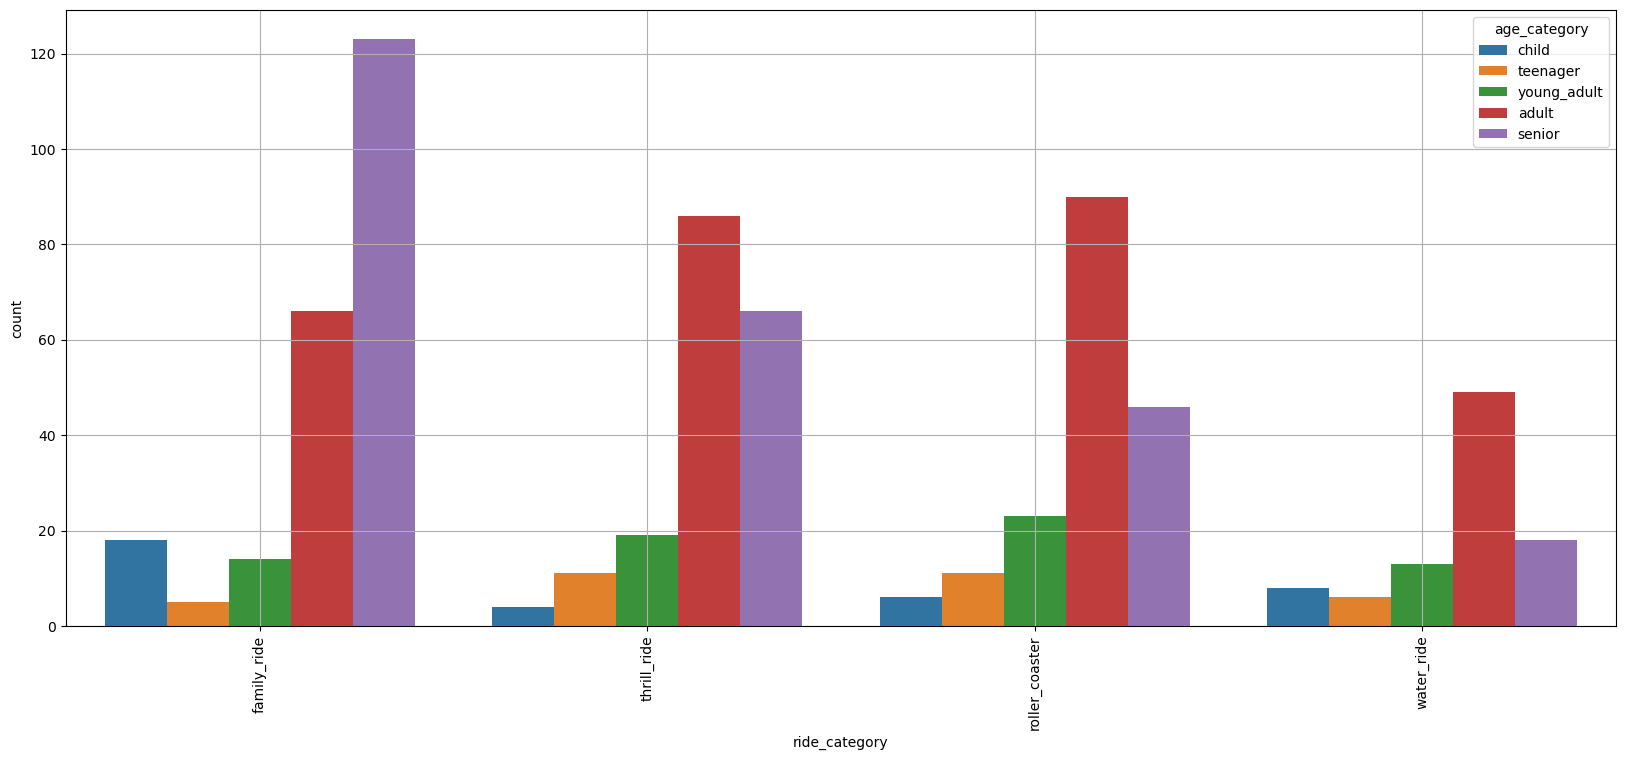

In [20]:
# Visualise incidents by ride_family and age_category
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20,8))
c1 = sns.countplot(x=df['ride_category'], hue=df['age_category'])
c1.set_xticklabels(c1.get_xticklabels(), rotation=90)
plt.grid()
plt.show()
None

### Above is a graphical representation of the differnt categories of ages and ride classification categories in relations to injury. We can see that in family friendly rides has a influx in senior age category getting injured. While all the other ride categories have the peak age group as adults. 

### Milestone 2

### Below we will categorize each injury into different categories such as deceased, hospital, pre-exisiting, unconcious, chest pain, seizure, physical, and sickness indicators. This data is then melted together and added to the dataset as individual columns to report different indicators as "0" or "1" a "0" indicates that that indicator does not show up for said injury; while a "1" shows us that this indicator is present in said injury case. We can see the graphical representation of each indicator and we can see that most cases included a prior sickness indicator.

In [21]:
def deceased_indicator(desc_text):
    deceased_string = ['passed away', 'died']    
    if any(x in desc_text.lower() for x in deceased_string):
        return 1
    else:
        return 0

df['deceased_ind'] = df['description'].apply(deceased_indicator)
df['deceased_ind'].value_counts()

deceased_ind
0    657
1     25
Name: count, dtype: int64

In [22]:
def hospital_indicator(desc_text):
    if 'hospital' in desc_text.lower():
        return 1
    else:
        return 0

df['hospital_ind'] = df['description'].apply(hospital_indicator)
df['hospital_ind'].value_counts()

hospital_ind
0    664
1     18
Name: count, dtype: int64

In [23]:
def pre_existing_ind(desc_text):
    pre_existing_string = ['pre-existing', 'pre existing'] 
    if any(x in desc_text.lower() for x in pre_existing_string):
        return 1
    else:
        return 0

df['pre_existing_ind'] = df['description'].apply(pre_existing_ind)
df['pre_existing_ind'].value_counts()

pre_existing_ind
0    565
1    117
Name: count, dtype: int64

In [24]:
def unconscious_ind(desc_text):
    unconscious_string = ['unconscious', 'syncope', 'passed out', 'fainted', 'collapsed', 'loss of consciousness', 'unresponsive']    
    if any(x in desc_text.lower() for x in unconscious_string):
        return 1
    else:
        return 0
df['unconscious_ind'] = df['description'].apply(unconscious_ind)
df['unconscious_ind'].value_counts()

unconscious_ind
0    619
1     63
Name: count, dtype: int64

In [25]:
def chest_pain_ind(desc_text):
    cp_string = ['chest pain']    
    if any(x in desc_text.lower() for x in cp_string):
        return 1
    else:
        return 0
df['chest_pain_ind'] = df['description'].apply(chest_pain_ind)
df['chest_pain_ind'].value_counts()

chest_pain_ind
0    599
1     83
Name: count, dtype: int64

In [26]:
def seizure_ind(desc_text):
    seizure_string = ['seizure']    
    if any(x in desc_text.lower() for x in seizure_string):
        return 1
    else:
        return 0
df['seizure_ind'] = df['description'].apply(seizure_ind)
df['seizure_ind'].value_counts()

seizure_ind
0    616
1     66
Name: count, dtype: int64

In [27]:
def physical_ind(desc_text):
    phys_string = ['fell', 'fracture', 'lacerated', 'tear', 'tripped', 'hit', 'laceration', 'fx', 'broke', 'injury', 'broken', 'struck', 'injured', 'hip']    
    if any(x in desc_text.lower() for x in phys_string):
        return 1
    else:
        return 0
df['physical_ind'] = df['description'].apply(physical_ind)
df['physical_ind'].value_counts(), 

(physical_ind
 0    534
 1    148
 Name: count, dtype: int64,)

In [28]:
def sickness_ind(desc_text):
    sickness_string = ['sickness', 'motion sickness', 'dizzy', 'ill', 'not feeling well', 'dizziness', 'vertigo']    
    if any(x in desc_text.lower() for x in sickness_string):
        return 1
    else:
        return 0
df['sickness_ind'] = df['description'].apply(sickness_ind)
df['sickness_ind'].value_counts(), 

(sickness_ind
 0    513
 1    169
 Name: count, dtype: int64,)

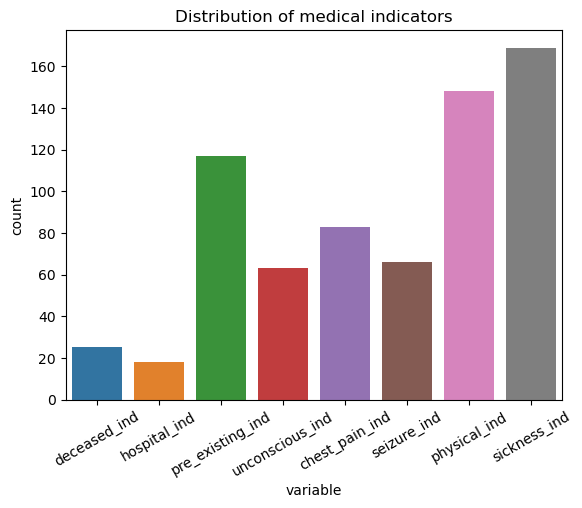

In [29]:
# Melt the dataframe and show a plot with the values of each medical column where the value is 1
df_melt = pd.melt(df[['deceased_ind', 'hospital_ind', 'pre_existing_ind', 'unconscious_ind', 'chest_pain_ind', 'seizure_ind', 
                 'physical_ind', 'sickness_ind']])
c1 = sns.countplot(data=df_melt.loc[df_melt['value']!=0], x='variable')
c1.set_xticklabels(c1.get_xticklabels(), rotation=30)
plt.title("Distribution of medical indicators")
plt.rcParams["figure.figsize"] = (12,6)
plt.ticklabel_format()
plt.show()
None

In [30]:
ohe_ride_cat = pd.get_dummies(df[['ride_category', 'Company', 'gender', 'age_category']])

In [31]:
# define our list of features
features = pd.DataFrame({
    'age' : df['age'],
    'day_of_month' : df['day_of_month'],
    'month_of_incident': df['month_of_incident'],
    'year_of_incident' : df['year_of_incident'],
    'deceased_ind' : df['deceased_ind'],
    'hospital_ind' : df['hospital_ind'],
    'pre_existing_ind' : df['pre_existing_ind'],
    'unconscious_ind' : df['unconscious_ind'],
    'chest_pain_ind' : df['chest_pain_ind'],
    'seizure_ind' : df['seizure_ind'],
    'physical_ind' : df['physical_ind'],
    'sickness_ind' : df['sickness_ind'],
})

In [32]:
# Create a new dataframe that takes our numerical features and our one hot encoded columns and concatenates them together
df2 = pd.concat([features, ohe_ride_cat], axis=1)
df2.head(10)

,age,day_of_month,month_of_incident,year_of_incident,deceased_ind,hospital_ind,pre_existing_ind,unconscious_ind,chest_pain_ind,seizure_ind,...,ride_category_water_ride,Company_Disney World,Company_Universal,gender_f,gender_m,age_category_child,age_category_teenager,age_category_young_adult,age_category_adult,age_category_senior
0,59,9,6,2022,0,0,1,0,0,0,...,False,True,False,True,False,False,False,False,True,False
1,68,5,10,2014,0,0,0,0,0,0,...,False,True,False,False,True,False,False,False,False,True
2,40,3,12,2009,0,0,0,0,0,0,...,False,True,False,True,False,False,False,False,True,False
3,83,7,8,2022,0,0,1,1,0,0,...,False,True,False,False,True,False,False,False,False,True
4,42,19,4,2022,0,0,1,0,0,0,...,False,True,False,True,False,False,False,False,True,False
5,67,5,7,2022,0,0,1,0,0,0,...,False,True,False,True,False,False,False,False,False,True
6,25,27,1,2022,0,0,1,0,0,1,...,False,True,False,True,False,False,False,True,False,False
7,69,18,12,2021,0,0,0,0,0,0,...,False,True,False,False,True,False,False,False,False,True
8,69,21,12,2021,0,0,0,0,0,0,...,False,True,False,True,False,False,False,False,False,True
9,68,16,9,2021,0,0,1,0,0,0,...,False,True,False,True,False,False,False,False,False,True


### Milestone 3

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

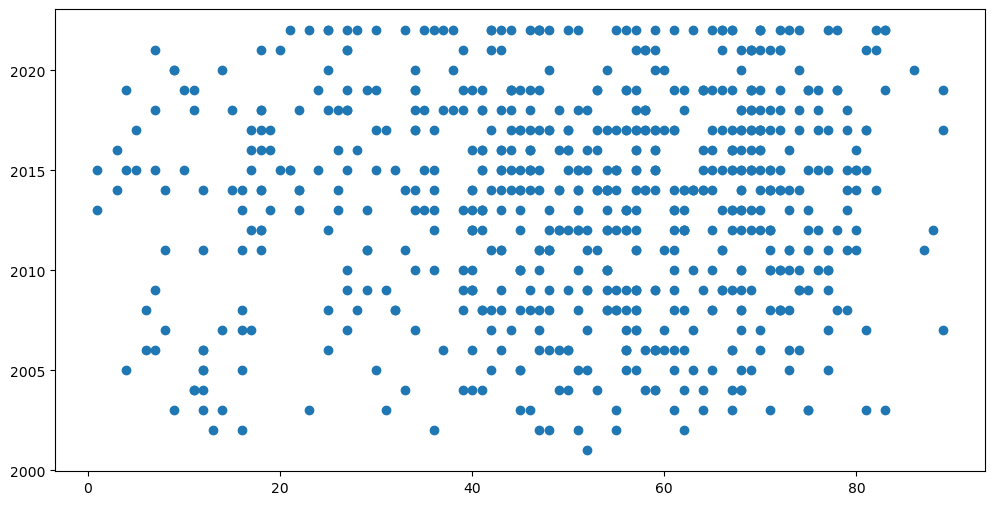

In [61]:
plt.scatter(df['age'],df['year_of_incident'])

In [49]:
X = df[['month_of_incident','day_of_month']]
Y = df['age']
X.head(10)

,month_of_incident,day_of_month
0,6,9
1,10,5
2,12,3
3,8,7
4,4,19
5,7,5
6,1,27
7,12,18
8,12,21
9,9,16


In [50]:
x_train, x_test,y_train,y_test = train_test_split(X,Y,test_size =0.2)
# print the data
x_train

,month_of_incident,day_of_month
186,4,16
375,1,19
142,12,29
458,11,27
422,6,24
...,...,...
336,7,31
204,9,9
22,3,14
665,6,10


In [51]:
from sklearn.linear_model import LinearRegression
clf = LinearRegression()

In [52]:
clf.fit(x_train,y_train)

LinearRegression()

In [53]:
clf.predict(x_test)

array([52.78608809, 50.43606722, 52.83766956, 51.99627882, 51.38487676,
       55.17585902, 52.88925102, 54.12388656, 52.04786029, 52.40893056,
       54.40971256, 53.06008269, 50.99588782, 55.03294602, 50.85297482,
       53.34590869, 53.15141422, 52.77425669, 50.76164329, 51.82544716,
       53.59198462, 50.17815989, 50.09865976, 48.99510582, 51.92861009,
       51.13880082, 50.18999129, 52.69475656, 51.40853955, 50.67031176,
       50.76164329, 52.52818076, 48.46320389, 49.52700775, 49.85258382,
       50.87663762, 52.03177302, 49.81283375, 51.09905076, 52.39709916,
       50.67031176, 52.03177302, 52.03177302, 51.15063222, 51.94469736,
       47.46281289, 50.61873029, 52.26601756, 50.46398589, 50.48764869,
       51.63095269, 50.34473569, 55.17585902, 51.57937122, 51.92861009,
       47.31989989, 51.25379516, 50.00732822, 53.74672902, 48.51478535,
       54.46129402, 51.85336582, 52.12310456, 49.33251329, 51.42462682,
       49.13801882, 50.22974136, 48.94352435, 49.28093182, 50.15

In [54]:
clf.score(x_test,y_test)

0.0006878547967150705